Archive:  ./data_heavy/10fg_2017_2018.zip
  inflating: ./data_heavy/goodland_10u_1.nc  

Resumen del dataset:
9×9×113232 Raster{Union{Missing, Float64}, 3} u10

Dimensiones detectadas:
(↓ X Mapped{Float32} [-102.6f0, …, -100.6f0] ForwardOrdered Regular Points,
→ Y Mapped{Float32} [40.5f0, …, 38.5f0] ReverseOrdered Regular Points,
↗ Ti Sampled{Dates.DateTime} [Dates.DateTime("1979-01-01T00:00:00"), …, Dates.DateTime("1992-12-31T23:00:00")] ForwardOrdered Irregular Points)
9×9 Raster{Union{Missing, Float64}, 2} u10
(↓ X Mapped{Float32} [-102.6f0, …, -100.6f0] ForwardOrdered Regular Points,
→ Y Mapped{Float32} [40.5f0, …, 38.5f0] ReverseOrdered Regular Points)


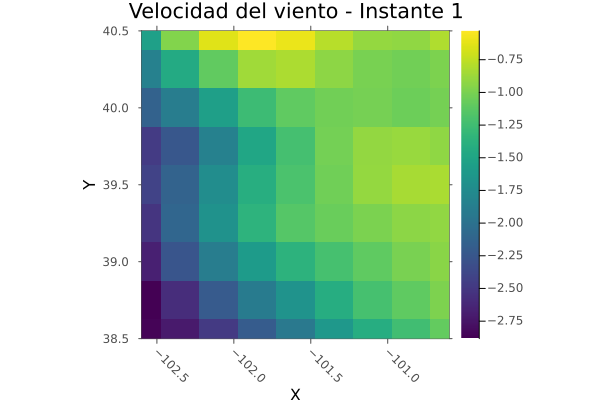

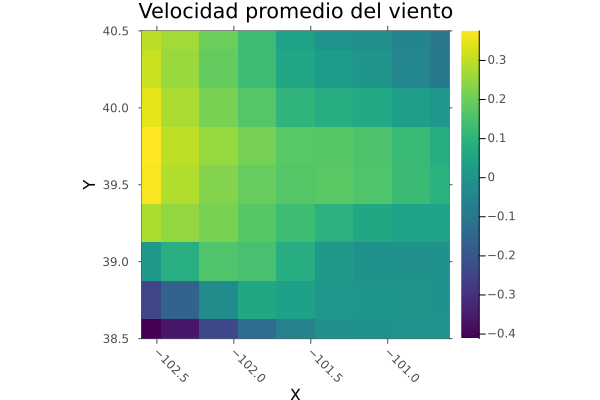

In [8]:
# ============================================================
# Lectura de NetCDF con múltiples bandas usando {Rasters}
# + Interpretación nativa de dimensiones
# + Cálculo estadístico con {Statistics}
# + Gestión de directorio local ./data_heavy/
# ============================================================

# -------------------------------
# 1. Cargar librerías necesarias
# -------------------------------
using Downloads
using Rasters
using NCDatasets
using Plots
using Statistics

# -------------------------------
# 2. Configuración de rutas y directorios
# -------------------------------
data_dir = "./data_heavy/"

# Crear el directorio si no existe (recursivo por defecto)
if !isdir(data_dir)
    mkpath(data_dir)
    println("Directorio creado: $data_dir")
end

url = "http://geocorp.co/wind/goodland_10u_1.zip"
zip_file = joinpath(data_dir, "10fg_2017_2018.zip")
nc_file = joinpath(data_dir, "goodland_10u_1.nc")

# -------------------------------
# 3. Descargar y descomprimir datos
# -------------------------------
# Descargar solo si el archivo no existe en la ruta destino
if !isfile(zip_file)
    println("Iniciando descarga en $zip_file...")
    Downloads.download(url, zip_file)
end

# Extraer el contenido dentro del directorio de datos pesados
# Se utiliza el flag -d para especificar el destino de extracción
run(`unzip -o $zip_file -d $data_dir`)

# -------------------------------
# 4. Leer el archivo NetCDF
# -------------------------------
# Rasters.jl utiliza lazy loading a través de DiskArrays.jl
# Solo se cargan en memoria los metadatos y punteros al archivo
if isfile(nc_file)
    cube = Raster(nc_file)
    
    println("\nResumen del dataset:")
    println(summary(cube))
    
    println("\nDimensiones detectadas:")
    println(dims(cube))
else
    error("El archivo NetCDF no se encuentra en la ruta: $nc_file")
end

# -------------------------------
# 5. Ejemplo: extraer un tiempo específico
# -------------------------------
# Ti() permite seleccionar mediante índice en la dimensión temporal
# Los recortes con cube[...] su puramente perezosos
cube_t1 = cube[Ti(1)]
println(summary(cube_t1))
println(dims(cube_t1))

p1 = plot(cube_t1, title="Velocidad del viento - Instante 1", c=:viridis)
display(p1)

# -------------------------------
# 6. Ejemplo: promedio temporal
# -------------------------------
# Reducir el cubo multidimensional promediando sobre el tiempo (Ti)
# Se usa dropdims para remover la dimensión residual de longitud 1
cube_mean = dropdims(mean(cube, dims=Ti), dims=Ti)

p2 = plot(cube_mean, title="Velocidad promedio del viento", c=:viridis)
display(p2)